In [82]:
# ============================================================
# LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np

# ============================================================
# CARGAR DATOS
# ============================================================
df = pd.read_csv('loan_dataset_150.csv')

print("Estado inicial:")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(df.isnull().sum())

# ============================================================
# PASO 1: Eliminar Loan_ID
# No aporta información predictiva, es solo un identificador
# ============================================================
df = df.drop(columns=['Loan_ID'])

# ============================================================
# PASO 2: Eliminar filas donde LoanAmount es nulo
# Sin monto no hay préstamo que evaluar — no se puede imputar
# ============================================================
filas_antes = len(df)
df = df.dropna(subset=['LoanAmount'])
filas_despues = len(df)
print(f"\nFilas eliminadas por LoanAmount nulo: {filas_antes - filas_despues}")

# ============================================================
# PASO 3: Rellenar nulos categóricos con "No especificado"
# Son datos del perfil del cliente — su ausencia es información
# válida, no la inventamos
# ============================================================
cols_categoricas_con_nulos = ['Gender', 'Credit_History']

for col in cols_categoricas_con_nulos:
    df[col] = df[col].fillna('No especificado')
    print(f"{col}: nulos reemplazados por 'No especificado'")

# ============================================================
# PASO 4: Corregir tipos de datos
# Credit_History y Dependents son categorías (0/1, 0/1/2/3+)
# no números continuos — el modelo no debe tratarlos como tal
# ============================================================
df['Credit_History'] = df['Credit_History'].astype(str)
df['Dependents'] = df['Dependents'].astype(str)

# ============================================================
# PASO 5: Verificar duplicados
# ============================================================
print(f"\nDuplicados: {df.duplicated().sum()}")
df = df.drop_duplicates()
# Nulos pendientes — categóricas
for col in ['Married', 'Self_Employed', 'Dependents']:
    df[col] = df[col].fillna('No especificado')

# Loan_Amount_Term — usamos moda porque 360 meses es el plazo
# estándar abrumador, imputar con ese valor es razonable
moda_term = df['Loan_Amount_Term'].mode()[0]
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(moda_term)
print(f"Loan_Amount_Term: nulos rellenados con {moda_term}")

# Verificar
print("\nNulos restantes:")
print(df.isnull().sum())
# ============================================================
# ESTADO FINAL
# ============================================================
print("\n--- DATASET LIMPIO ---")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\nNulos restantes:")
print(df.isnull().sum())
print("\nTipos de datos:")
print(df.dtypes)

# Guardar
df.to_csv('loan_dataset_limpio.csv', index=False)
print("\n✅ Guardado como 'loan_dataset_limpio.csv'")

Estado inicial:
Filas: 614 | Columnas: 13
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Filas eliminadas por LoanAmount nulo: 22
Gender: nulos reemplazados por 'No especificado'
Credit_History: nulos reemplazados por 'No especificado'

Duplicados: 0
Loan_Amount_Term: nulos rellenados con 360.0

Nulos restantes:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

--- DATASET LIMPIO ---
Filas: 592 | Columnas: 12

Nulos restantes:
Gender               0
Married              0
Depe

In [83]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [84]:
# ============================================================
# LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns












In [85]:
# Estilo general de los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [86]:
# ============================================================
# CARGAR DATASET LIMPIO
# ============================================================
df = pd.read_csv('loan_dataset_limpio.csv')

# Crear columna TotalIncome
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Columna para saber si va solo o acompañado
df['Tiene_Cosolicante'] = df['CoapplicantIncome'].apply(
    lambda x: 'Con co-solicitante' if x > 0 else 'Solo'
)
# lambda es una función rápida de una línea:
# si CoapplicantIncome > 0 → tiene co-solicitante, sino → va solo

=== APROBADOS VS RECHAZADOS ===
             Cantidad  Porcentaje
Loan_Status                      
Y                 411        69.4
N                 181        30.6


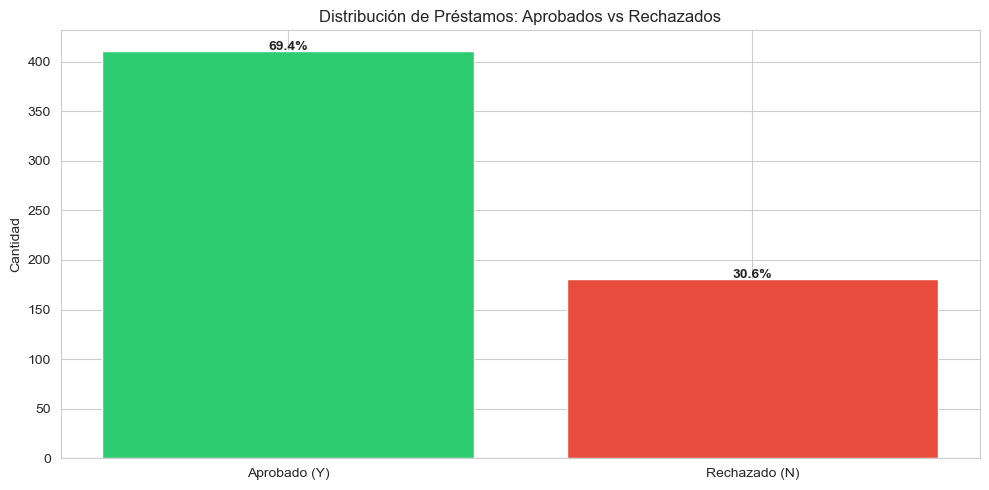

In [87]:
# ============================================================
# 1. APROBADOS VS RECHAZADOS
# ============================================================
conteo = df['Loan_Status'].value_counts()
porcentaje = df['Loan_Status'].value_counts(normalize=True) * 100
# normalize=True convierte los conteos en proporciones (0 a 1)
# multiplicamos por 100 para tener porcentaje

print("=== APROBADOS VS RECHAZADOS ===")
print(pd.DataFrame({'Cantidad': conteo, 'Porcentaje': porcentaje.round(1)}))

fig, ax = plt.subplots()
bars = ax.bar(['Aprobado (Y)', 'Rechazado (N)'], conteo.values,
              color=['#2ecc71', '#e74c3c'])
# Añadir etiquetas encima de cada barra
for bar, pct in zip(bars, porcentaje.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{pct:.1f}%', ha='center', fontweight='bold')
ax.set_title('Distribución de Préstamos: Aprobados vs Rechazados')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.savefig('1_aprobados_vs_rechazados.png', dpi=150)
plt.show()



=== HISTORIAL CREDITICIO ===
Cantidades:
Loan_Status       N    Y
Credit_History          
0.0              78    7
1.0              91  367
No especificado  12   37

Porcentajes:
Loan_Status         N     Y
Credit_History             
0.0              91.8   8.2
1.0              19.9  80.1
No especificado  24.5  75.5


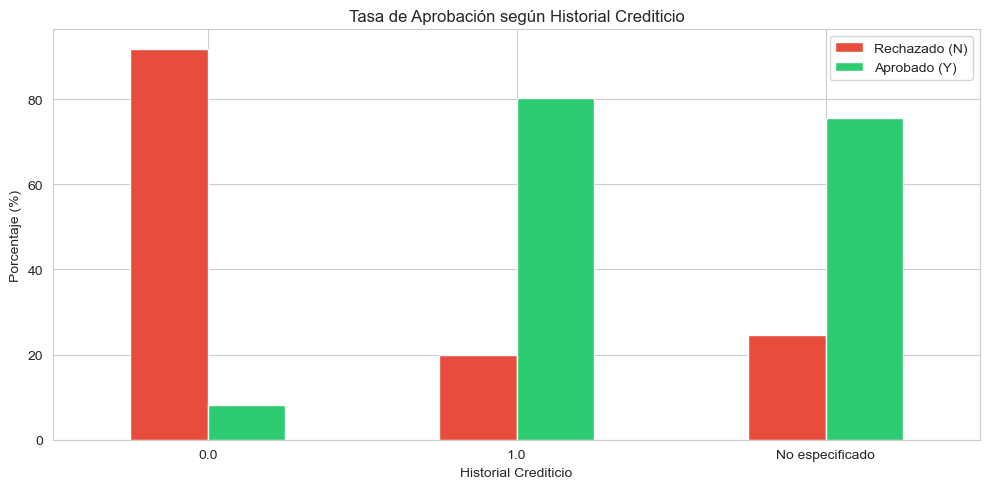

In [88]:
# ============================================================
# 2. HISTORIAL CREDITICIO VS APROBACIÓN
# ============================================================
tabla_credito = pd.crosstab(df['Credit_History'], df['Loan_Status'])
tabla_credito_pct = pd.crosstab(df['Credit_History'], df['Loan_Status'],
                                 normalize='index') * 100
# normalize='index' calcula el % dentro de cada fila
# o sea: del total de personas con historial 1.0, ¿qué % fue aprobado?

print("\n=== HISTORIAL CREDITICIO ===")
print("Cantidades:")
print(tabla_credito)
print("\nPorcentajes:")
print(tabla_credito_pct.round(1))

tabla_credito_pct.plot(kind='bar', color=['#e74c3c', '#2ecc71'], rot=0)
plt.title('Tasa de Aprobación según Historial Crediticio')
plt.xlabel('Historial Crediticio')
plt.ylabel('Porcentaje (%)')
plt.legend(['Rechazado (N)', 'Aprobado (Y)'])
plt.tight_layout()
plt.savefig('2_historial_crediticio.png', dpi=150)
plt.show()



=== DEPENDENTS ===
Cantidades:
Loan_Status    N    Y
Dependents           
0            101  233
1             35   63
2             23   75
3+            16   33

Porcentajes:
Loan_Status     N     Y
Dependents             
0            30.2  69.8
1            35.7  64.3
2            23.5  76.5
3+           32.7  67.3


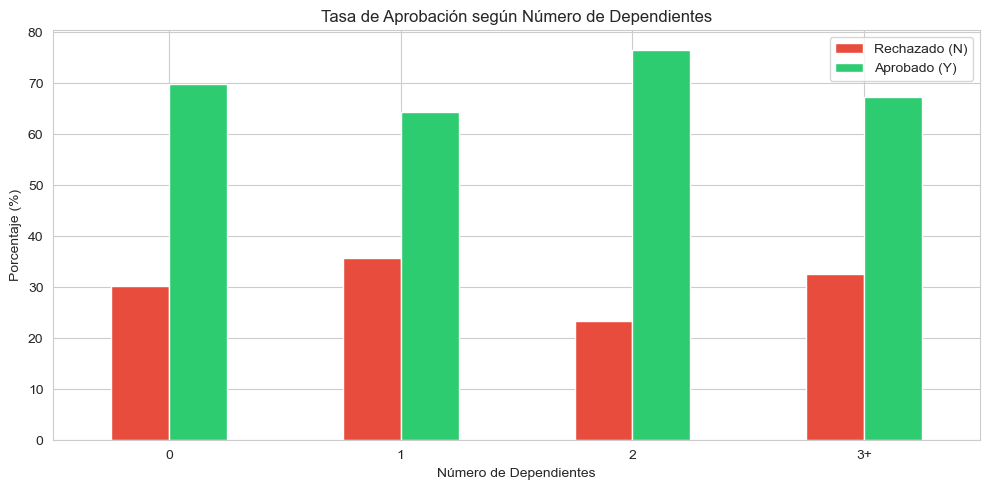

In [89]:
# ============================================================
# 3. DEPENDENTS VS APROBACIÓN
# ============================================================
tabla_dep = pd.crosstab(df['Dependents'], df['Loan_Status'])
tabla_dep_pct = pd.crosstab(df['Dependents'], df['Loan_Status'],
                              normalize='index') * 100

print("\n=== DEPENDENTS ===")
print("Cantidades:")
print(tabla_dep)
print("\nPorcentajes:")
print(tabla_dep_pct.round(1))

tabla_dep_pct.plot(kind='bar', color=['#e74c3c', '#2ecc71'], rot=0)
plt.title('Tasa de Aprobación según Número de Dependientes')
plt.xlabel('Número de Dependientes')
plt.ylabel('Porcentaje (%)')
plt.legend(['Rechazado (N)', 'Aprobado (Y)'])
plt.tight_layout()
plt.savefig('3_dependents.png', dpi=150)
plt.show()



=== INGRESOS TOTALES ===
Aprobados:
count      411.0
mean      6901.0
std       5843.0
min       1963.0
25%       4177.0
50%       5428.0
75%       7360.0
max      63337.0
Name: TotalIncome, dtype: float64

Rechazados:
count      181.0
mean      7379.0
std       7880.0
min       1442.0
25%       4166.0
50%       5282.0
75%       7686.0
max      81000.0
Name: TotalIncome, dtype: float64


C:\Users\asenc\AppData\Local\Temp\ipykernel_14136\3893113165.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Loan_Status', y='TotalIncome', data=df,


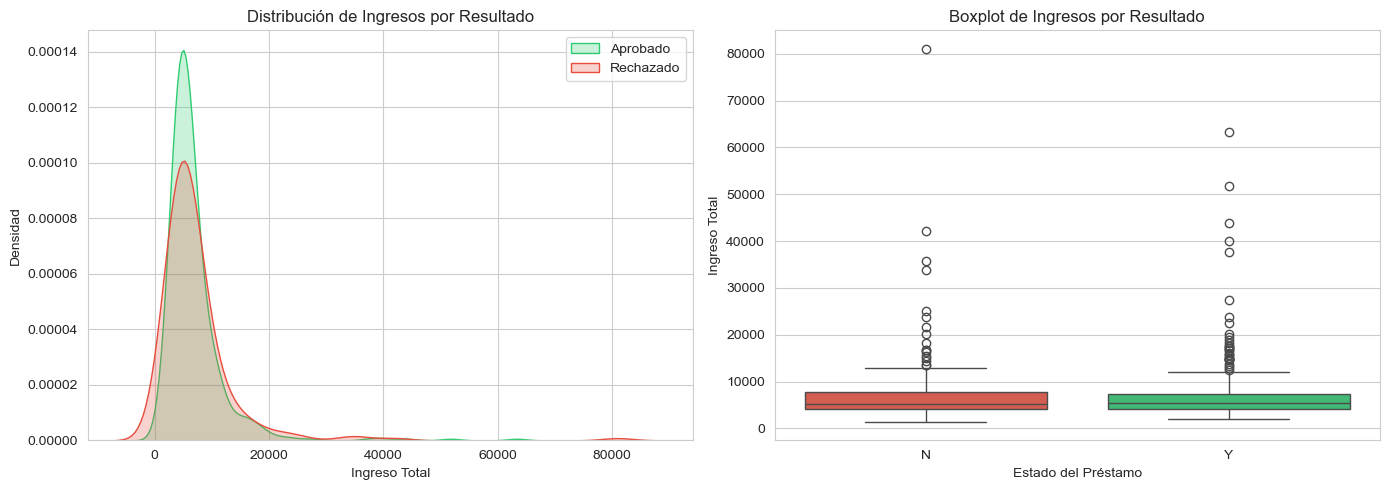

In [90]:
# ============================================================
# 4. INGRESOS VS APROBACIÓN
# ============================================================
aprobados = df[df['Loan_Status'] == 'Y']['TotalIncome']
rechazados = df[df['Loan_Status'] == 'N']['TotalIncome']
# Filtramos en dos grupos para comparar sus distribuciones

print("\n=== INGRESOS TOTALES ===")
print("Aprobados:")
print(aprobados.describe().round(0))
print("\nRechazados:")
print(rechazados.describe().round(0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Creamos dos gráficos lado a lado

# Curva de distribución (KDE)
sns.kdeplot(aprobados, ax=ax1, color='#2ecc71', fill=True, label='Aprobado')
sns.kdeplot(rechazados, ax=ax1, color='#e74c3c', fill=True, label='Rechazado')
# KDE = Kernel Density Estimation, estima la distribución continua
# fill=True colorea el área bajo la curva
ax1.set_title('Distribución de Ingresos por Resultado')
ax1.set_xlabel('Ingreso Total')
ax1.set_ylabel('Densidad')
ax1.legend()

# Boxplot para ver mediana y outliers
sns.boxplot(x='Loan_Status', y='TotalIncome', data=df,
            palette={'Y': '#2ecc71', 'N': '#e74c3c'}, ax=ax2)
# El boxplot muestra: caja = rango intercuartílico (25%-75%)
# línea del medio = mediana, puntos sueltos = outliers
ax2.set_title('Boxplot de Ingresos por Resultado')
ax2.set_xlabel('Estado del Préstamo')
ax2.set_ylabel('Ingreso Total')

plt.tight_layout()
plt.savefig('4_ingresos.png', dpi=150)
plt.show()


=== CO-SOLICITANTE ===
Cantidades:
Loan_Status          N    Y
Tiene_Cosolicante          
Con co-solicitante  92  239
Solo                89  172

Porcentajes:
Loan_Status            N     Y
Tiene_Cosolicante             
Con co-solicitante  27.8  72.2
Solo                34.1  65.9


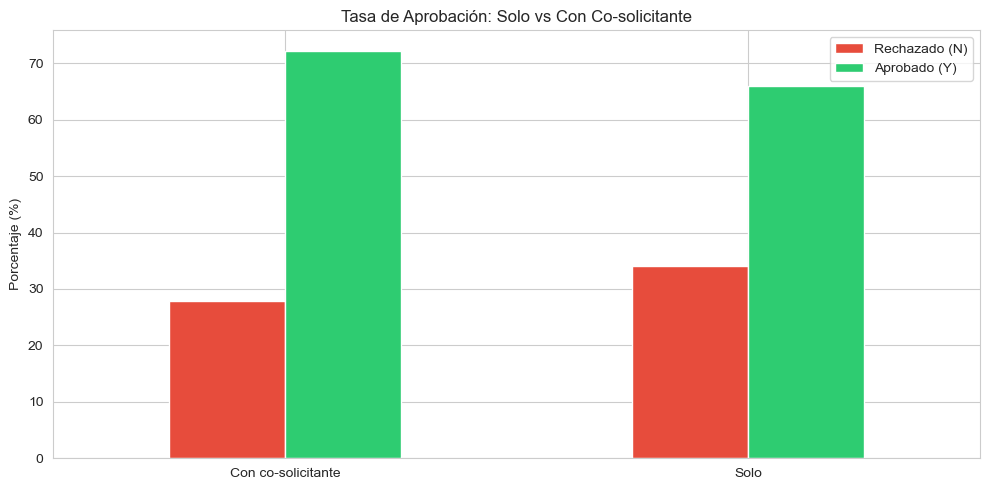

In [91]:
# ============================================================
# 5. CO-SOLICITANTE VS APROBACIÓN
# ============================================================
tabla_cos = pd.crosstab(df['Tiene_Cosolicante'], df['Loan_Status'])
tabla_cos_pct = pd.crosstab(df['Tiene_Cosolicante'], df['Loan_Status'],
                              normalize='index') * 100

print("\n=== CO-SOLICITANTE ===")
print("Cantidades:")
print(tabla_cos)
print("\nPorcentajes:")
print(tabla_cos_pct.round(1))

tabla_cos_pct.plot(kind='bar', color=['#e74c3c', '#2ecc71'], rot=0)
plt.title('Tasa de Aprobación: Solo vs Con Co-solicitante')
plt.xlabel('')
plt.ylabel('Porcentaje (%)')
plt.legend(['Rechazado (N)', 'Aprobado (Y)'])
plt.tight_layout()
plt.savefig('5_cosolicante.png', dpi=150)
plt.show()

=== RATIO PRÉSTAMO/INGRESO POR RESULTADO ===
             count    mean     std     min     25%     50%     75%     max
Loan_Status                                                               
N            181.0  0.0247  0.0096  0.0025  0.0193  0.0238  0.0289  0.0692
Y            411.0  0.0233  0.0076  0.0027  0.0194  0.0243  0.0281  0.0827

=== RATIO MEDIANO POR RESULTADO Y HISTORIAL CREDITICIO ===
Loan_Status  Credit_History 
N            0.0                0.0250
             1.0                0.0236
             No especificado    0.0243
Y            0.0                0.0240
             1.0                0.0241
             No especificado    0.0252
Name: Ratio_Prestamo_Ingreso, dtype: float64


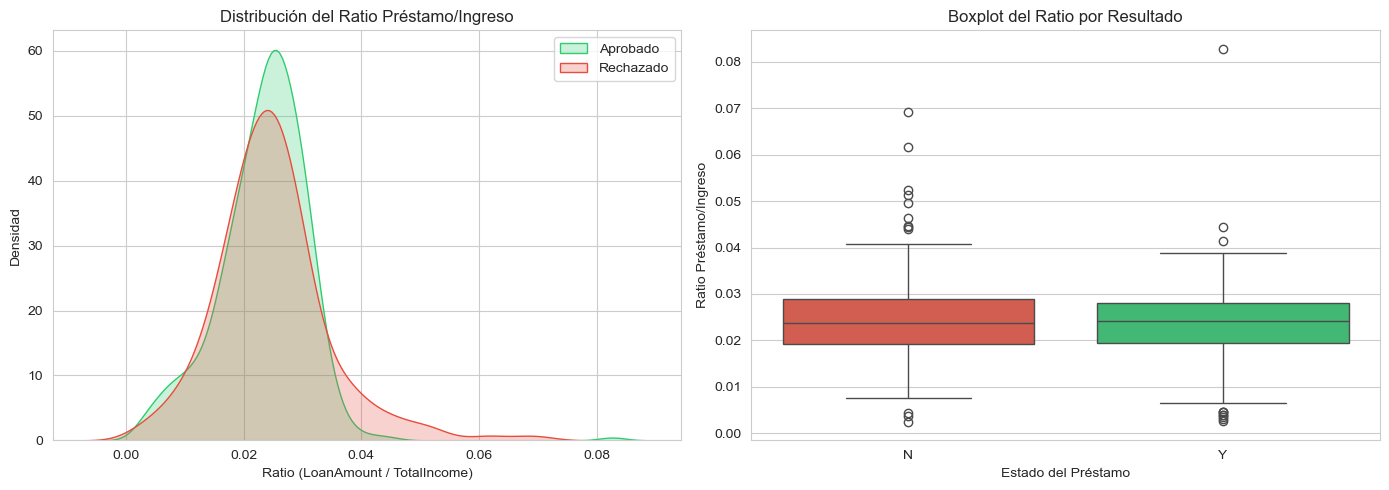

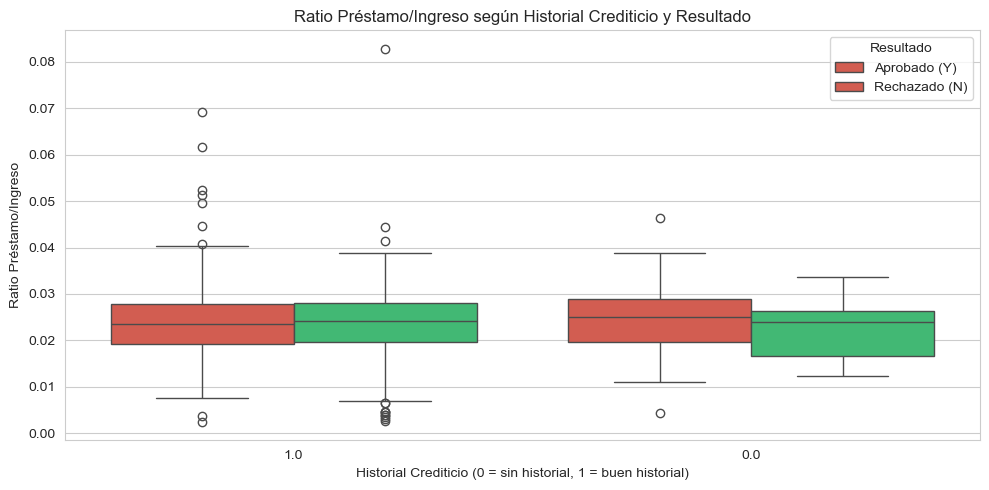

In [92]:
# ============================================================
# ANÁLISIS: RATIO PRÉSTAMO / INGRESO
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Cargar dataset limpio
df = pd.read_csv('loan_dataset_limpio.csv')

# Crear variables necesarias
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

df['Ratio_Prestamo_Ingreso'] = df['LoanAmount'] / df['TotalIncome']
# Este ratio indica cuánto representa el préstamo respecto al ingreso total
# Ratio = 0.05 significa que el préstamo es el 5% del ingreso mensual
# Entre más alto, más carga financiera para el solicitante

# ============================================================
# NÚMEROS: estadísticas por grupo
# ============================================================
print("=== RATIO PRÉSTAMO/INGRESO POR RESULTADO ===")
print(df.groupby('Loan_Status')['Ratio_Prestamo_Ingreso']
      .describe().round(4))
# describe() muestra count, mean, std, min, percentiles y max
# Nos interesa comparar la mediana (50%) entre aprobados y rechazados

print("\n=== RATIO MEDIANO POR RESULTADO Y HISTORIAL CREDITICIO ===")
tabla = df.groupby(['Loan_Status', 'Credit_History']
                   )['Ratio_Prestamo_Ingreso'].median().round(4)
print(tabla)
# Aquí veremos si el historial crediticio cambia el patrón del ratio
# Esta es la tabla que confirma o refuta tu hipótesis

# ============================================================
# GRÁFICO 1: Curva de distribución del ratio
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

aprobados = df[df['Loan_Status'] == 'Y']['Ratio_Prestamo_Ingreso']
rechazados = df[df['Loan_Status'] == 'N']['Ratio_Prestamo_Ingreso']

sns.kdeplot(aprobados, ax=ax1, color='#2ecc71', fill=True, label='Aprobado')
sns.kdeplot(rechazados, ax=ax1, color='#e74c3c', fill=True, label='Rechazado')
ax1.set_title('Distribución del Ratio Préstamo/Ingreso')
ax1.set_xlabel('Ratio (LoanAmount / TotalIncome)')
ax1.set_ylabel('Densidad')
ax1.legend()
# Si tu hipótesis es correcta, la curva roja (rechazados)
# debería tener más peso hacia la derecha (ratios más altos)

sns.boxplot(x='Loan_Status', y='Ratio_Prestamo_Ingreso', data=df,
            hue='Loan_Status', palette={'Y': '#2ecc71', 'N': '#e74c3c'},
            ax=ax2, legend=False)
ax2.set_title('Boxplot del Ratio por Resultado')
ax2.set_xlabel('Estado del Préstamo')
ax2.set_ylabel('Ratio Préstamo/Ingreso')

plt.tight_layout()
plt.savefig('6_ratio_prestamo_ingreso.png', dpi=150)
plt.show()

# ============================================================
# GRÁFICO 2: Ratio cruzado con historial crediticio
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(x='Credit_History', y='Ratio_Prestamo_Ingreso',
            hue='Loan_Status',
            data=df[df['Credit_History'] != 'No especificado'],
            # excluimos "No especificado" para que el gráfico sea más claro
            palette={'Y': '#2ecc71', 'N': '#e74c3c'},
            ax=ax)

ax.set_title('Ratio Préstamo/Ingreso según Historial Crediticio y Resultado')
ax.set_xlabel('Historial Crediticio (0 = sin historial, 1 = buen historial)')
ax.set_ylabel('Ratio Préstamo/Ingreso')
ax.legend(title='Resultado', labels=['Aprobado (Y)', 'Rechazado (N)'])
plt.tight_layout()
plt.savefig('7_ratio_vs_historial.png', dpi=150)
plt.show()

In [93]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [94]:
df = pd.read_csv('loan_dataset_limpio.csv')

# Recrear variables que calculamos en el EDA
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Ratio_Prestamo_Ingreso'] = df['LoanAmount'] / df['TotalIncome']

In [95]:
# PASO 1: ENCODING — convertir texto a números
# ============================================================
le = LabelEncoder()
# LabelEncoder aprende los valores únicos de una columna
# y los convierte a números (0, 1, 2...)

cols_categoricas = ['Gender', 'Married', 'Dependents', 'Education',
                    'Self_Employed', 'Credit_History', 'Property_Area']

for col in cols_categoricas:
    df[col] = le.fit_transform(df[col].astype(str))
    # fit_transform en cada columna:
    # fit → aprende los valores únicos
    # transform → los convierte a números
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    # Imprimimos el mapeo para saber qué número corresponde a qué valor

# Variable objetivo
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
# Usamos map en vez de LabelEncoder para controlar exactamente
# qué valor recibe cada categoría — Y=1 (aprobado), N=0 (rechazado)

Gender: {'Female': np.int64(0), 'Male': np.int64(1), 'No especificado': np.int64(2)}
Married: {'No': np.int64(0), 'No especificado': np.int64(1), 'Yes': np.int64(2)}
Dependents: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3+': np.int64(3), 'nan': np.int64(4)}
Education: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
Self_Employed: {'No': np.int64(0), 'No especificado': np.int64(1), 'Yes': np.int64(2)}
Credit_History: {'0.0': np.int64(0), '1.0': np.int64(1), 'No especificado': np.int64(2)}
Property_Area: {'Rural': np.int64(0), 'Semiurban': np.int64(1), 'Urban': np.int64(2)}


In [96]:
# PASO 2: SEPARAR X e y
# ============================================================
X = df.drop(columns=['Loan_Status'])
# X = todas las columnas menos la que queremos predecir

y = df['Loan_Status']
# y = la columna que queremos predecir

print(f"\nVariables predictoras: {X.shape[1]}")
print(f"Registros: {X.shape[0]}")


Variables predictoras: 13
Registros: 592


In [97]:
# PASO 3: TRAIN/TEST SPLIT
# ============================================================
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Escalar datos para Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# fit_transform en train → aprende la escala de los datos de entrenamiento
# transform en test → aplica la misma escala sin reaprender
# IMPORTANTE: nunca hacer fit en el test, porque estarías
# "contaminando" el modelo con información que no debería ver

In [98]:
# PASO 4: ENTRENAR MODELOS
# ============================================================

# --- Logistic Regression (usa datos escalados) ---
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=2000         # subimos el límite por si acaso
)
lr.fit(X_train_scaled, y_train)  # ← datos escalados

# --- Random Forest (usa datos originales, no necesita escala) ---
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)  # ← datos sin escalar

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [102]:
# PASO 5: PREDICCIONES Y MÉTRICAS
# ============================================================
y_pred_lr = lr.predict(X_test_scaled)  # ← scaled
y_pred_rf = rf.predict(X_test)         # ← sin escalar

print("\n=== LOGISTIC REGRESSION ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2%}")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Rechazado', 'Aprobado']))
# classification_report muestra para cada clase:
# precision  → de los que predije como X, ¿cuántos realmente eran X?
# recall     → de los que realmente eran X, ¿cuántos detecté?
# f1-score   → balance entre precision y recall

print("\n=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Rechazado', 'Aprobado']))
# AJUSTE DE UMBRAL — maximizar detección de rechazos
# ============================================================
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

print("=== BUSCANDO UMBRAL ÓPTIMO ===")

# Obtener probabilidades en vez de predicciones directas
# predict_proba devuelve [prob_rechazado, prob_aprobado] para cada fila
prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
prob_rf = rf.predict_proba(X_test)[:, 1]

# Probar diferentes umbrales y ver cómo cambia el recall de rechazados
umbrales = [0.5, 0.45, 0.40, 0.35, 0.30]

print("\n--- LOGISTIC REGRESSION ---")
print(f"{'Umbral':<10} {'Accuracy':<12} {'Recall Rechazado':<20} {'Recall Aprobado'}")
for u in umbrales:
    pred = (prob_lr >= u).astype(int)
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, 
                                   target_names=['Rechazado', 'Aprobado'],
                                   output_dict=True)
    recall_r = report['Rechazado']['recall']
    recall_a = report['Aprobado']['recall']
    print(f"{u:<10} {acc:.2%}      {recall_r:.2%}               {recall_a:.2%}")

print("\n--- RANDOM FOREST ---")
print(f"{'Umbral':<10} {'Accuracy':<12} {'Recall Rechazado':<20} {'Recall Aprobado'}")
for u in umbrales:
    pred = (prob_rf >= u).astype(int)
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred,
                                   target_names=['Rechazado', 'Aprobado'],
                                   output_dict=True)
    recall_r = report['Rechazado']['recall']
    recall_a = report['Aprobado']['recall']
    print(f"{u:<10} {acc:.2%}      {recall_r:.2%}               {recall_a:.2%}")

# Aplicar el umbral más estricto (0.40) al mejor modelo
print("\n=== MODELO FINAL CON UMBRAL 0.40 ===")
pred_final = (prob_rf >= 0.40).astype(int)
print(f"Accuracy: {accuracy_score(y_test, pred_final):.2%}")
print(classification_report(y_test, pred_final,
                             target_names=['Rechazado', 'Aprobado']))


=== LOGISTIC REGRESSION ===
Accuracy: 78.15%
              precision    recall  f1-score   support

   Rechazado       0.65      0.61      0.63        36
    Aprobado       0.84      0.86      0.85        83

    accuracy                           0.78       119
   macro avg       0.74      0.73      0.74       119
weighted avg       0.78      0.78      0.78       119


=== RANDOM FOREST ===
Accuracy: 78.99%
              precision    recall  f1-score   support

   Rechazado       0.76      0.44      0.56        36
    Aprobado       0.80      0.94      0.86        83

    accuracy                           0.79       119
   macro avg       0.78      0.69      0.71       119
weighted avg       0.79      0.79      0.77       119

=== BUSCANDO UMBRAL ÓPTIMO ===

--- LOGISTIC REGRESSION ---
Umbral     Accuracy     Recall Rechazado     Recall Aprobado
0.5        78.15%      61.11%               85.54%
0.45       79.83%      50.00%               92.77%
0.4        80.67%      44.44%        

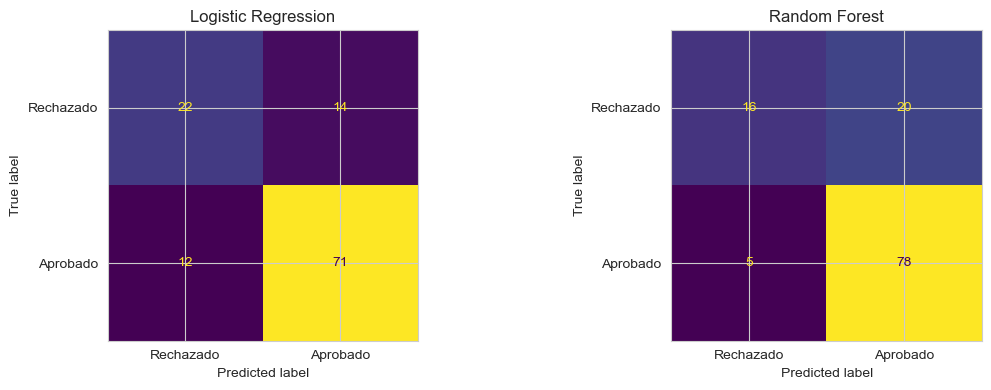

In [103]:
# PASO 6: MATRICES DE CONFUSIÓN
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# La matriz de confusión muestra:
# - Verdaderos positivos (aprobados correctamente)
# - Verdaderos negativos (rechazados correctamente)
# - Falsos positivos (rechazados predichos como aprobados) ← el costoso
# - Falsos negativos (aprobados predichos como rechazados)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Rechazado', 'Aprobado']
).plot(ax=ax1, colorbar=False)
ax1.set_title('Logistic Regression')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Rechazado', 'Aprobado']
).plot(ax=ax2, colorbar=False)
ax2.set_title('Random Forest')

plt.tight_layout()
plt.savefig('8_matrices_confusion.png', dpi=150)
plt.show()

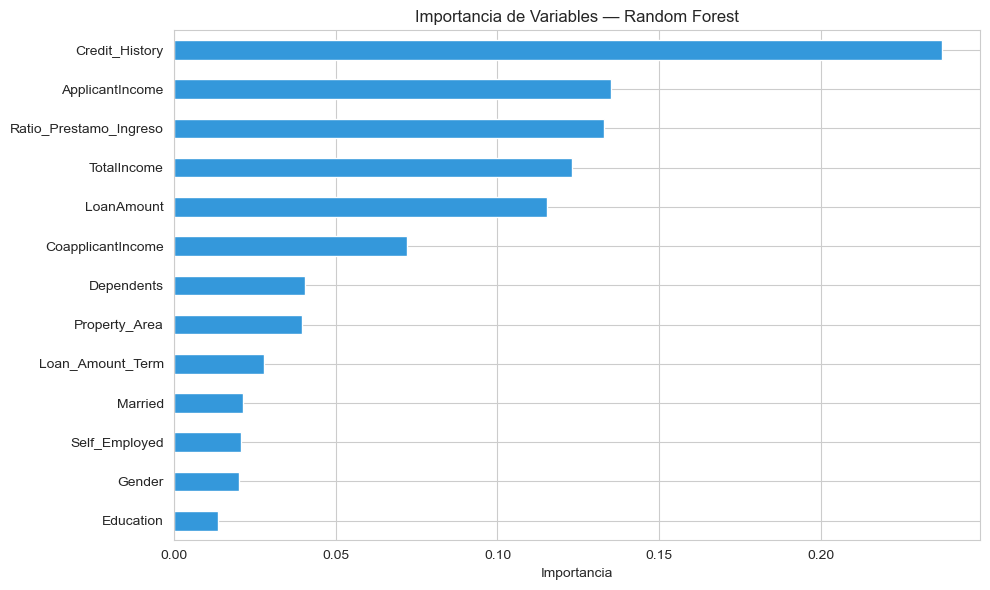


=== IMPORTANCIA DE VARIABLES ===
Credit_History            0.2371
ApplicantIncome           0.1350
Ratio_Prestamo_Ingreso    0.1330
TotalIncome               0.1231
LoanAmount                0.1153
CoapplicantIncome         0.0721
Dependents                0.0406
Property_Area             0.0396
Loan_Amount_Term          0.0279
Married                   0.0214
Self_Employed             0.0207
Gender                    0.0203
Education                 0.0138
dtype: float64


In [104]:
# PASO 7: IMPORTANCIA DE VARIABLES (Random Forest)
# ============================================================
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)
# feature_importances_ indica cuánto aportó cada variable
# al poder predictivo del modelo — confirmaremos si Credit_History
# y Ratio_Prestamo_Ingreso son las más importantes como predijimos

importancias.plot(kind='barh', color='#3498db', figsize=(10, 6))
plt.title('Importancia de Variables — Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('9_importancia_variables.png', dpi=150)
plt.show()

print("\n=== IMPORTANCIA DE VARIABLES ===")
print(importancias.sort_values(ascending=False).round(4))

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 4.2/101.7 MB 22.3 MB/s eta 0:00:05
   --- ------------------------------------ 8.4/101.7 MB 21.3 MB/s eta 0:00:05
   ----- ---------------------------------- 13.4/101.7 MB 21.6 MB/s eta 0:00:05
   ------- -------------------------------- 19.4/101.7 MB 23.2 MB/s eta 0:00:04
   ---------- ----------------------------- 25.4/101.7 MB 24.4 MB/s eta 0:00:04
   ----------- ---------------------------- 29.9/101.7 MB 23.6 MB/s eta 0:00:04
   -------------- ------------------------- 37.5/101.7 MB 25.2 MB/s eta 0:00:03
   ----------------- ---------------------- 44.0/101.7 MB 26.0 MB/s eta 0:00:03
   -------------------- ------------------- 50.9/101.7 MB 26.6 MB/s eta 0:00:02
   ---------------------- ----------------- 57.4/101.7 MB 26.9 MB/s eta 0:00:02
   ------------------------- -------------- 64.7/101.7 MB 27.7 MB/s eta 0:00:02
   ---------------------------- ----------- 72.6/10

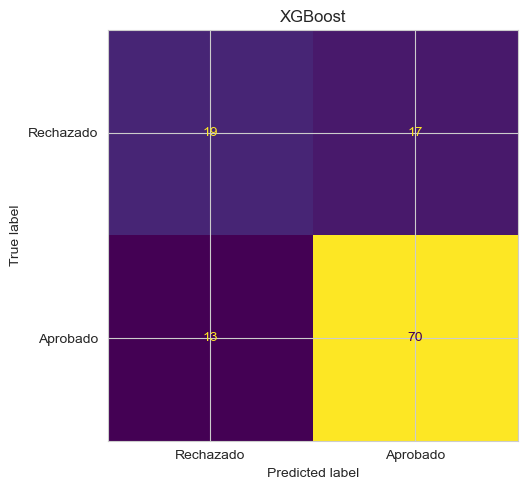


--- XGBOOST UMBRALES ---
Umbral     Accuracy     Recall Rechazado     Recall Aprobado
0.5        74.79%      52.78%               84.34%
0.45       76.47%      52.78%               86.75%
0.4        79.83%      50.00%               92.77%
0.35       78.99%      44.44%               93.98%
0.3        81.51%      44.44%               97.59%


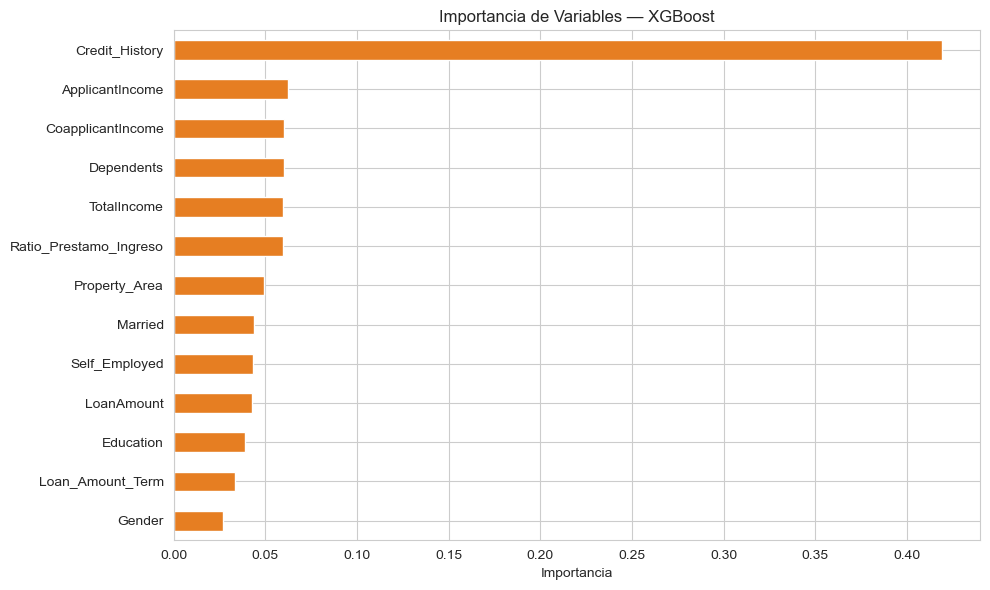


=== IMPORTANCIA XGBOOST ===
Credit_History            0.4189
ApplicantIncome           0.0625
CoapplicantIncome         0.0603
Dependents                0.0600
TotalIncome               0.0598
Ratio_Prestamo_Ingreso    0.0596
Property_Area             0.0495
Married                   0.0441
Self_Employed             0.0434
LoanAmount                0.0426
Education                 0.0387
Loan_Amount_Term          0.0335
Gender                    0.0270
dtype: float32


In [109]:
import sys
!{sys.executable} -m pip install xgboost
# ============================================================
# XGBOOST
# ============================================================
from xgboost import XGBClassifier

# Necesitamos convertir y_train e y_test a números si no lo están
# XGBoost requiere 0 y 1, no 'Y' y 'N'
# Si ya los tienes como 0 y 1 desde el encoding anterior, esto no cambia nada

xgb = XGBClassifier(
    n_estimators=100,      # 100 árboles en secuencia
    learning_rate=0.1,     # qué tan rápido aprende de cada error
                           # muy alto = aprende rápido pero se equivoca
                           # muy bajo = aprende lento pero más preciso
    max_depth=4,           # profundidad máxima de cada árbol
                           # más profundo = más complejo = riesgo de overfitting
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    # equivalente a class_weight='balanced' — le dice al modelo
    # que pese más los rechazados porque son minoría
    random_state=42,
    eval_metric='logloss',  # métrica interna de evaluación
    verbosity=0             # silencia mensajes internos
)

xgb.fit(X_train, y_train)
# XGBoost usa datos sin escalar igual que Random Forest

y_pred_xgb = xgb.predict(X_test)

print("=== XGBOOST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2%}")
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Rechazado', 'Aprobado']))

# Matriz de confusión
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb),
    display_labels=['Rechazado', 'Aprobado']
).plot(colorbar=False)
plt.title('XGBoost')
plt.tight_layout()
plt.savefig('10_confusion_xgboost.png', dpi=150)
plt.show()

# Ajuste de umbral igual que antes
prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n--- XGBOOST UMBRALES ---")
print(f"{'Umbral':<10} {'Accuracy':<12} {'Recall Rechazado':<20} {'Recall Aprobado'}")
for u in umbrales:
    pred = (prob_xgb >= u).astype(int)
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred,
                                   target_names=['Rechazado', 'Aprobado'],
                                   output_dict=True,
                                   zero_division=0)
    recall_r = report['Rechazado']['recall']
    recall_a = report['Aprobado']['recall']
    print(f"{u:<10} {acc:.2%}      {recall_r:.2%}               {recall_a:.2%}")

# Importancia de variables
importancias_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
importancias_xgb = importancias_xgb.sort_values(ascending=True)

importancias_xgb.plot(kind='barh', color='#e67e22', figsize=(10, 6))
plt.title('Importancia de Variables — XGBoost')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('11_importancia_xgboost.png', dpi=150)
plt.show()

print("\n=== IMPORTANCIA XGBOOST ===")
print(importancias_xgb.sort_values(ascending=False).round(4))